In [0]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = "/Volumes/workspace/default/netflixdata/netflix_titles_featured.csv"
df = pd.read_csv(file_path)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   show_id                  8807 non-null   object 
 1   type                     8807 non-null   object 
 2   title                    8807 non-null   object 
 3   director                 8807 non-null   object 
 4   cast                     8807 non-null   object 
 5   country                  8807 non-null   object 
 6   date_added               8807 non-null   object 
 7   release_year             8807 non-null   int64  
 8   rating                   8807 non-null   object 
 9   duration                 8807 non-null   object 
 10  listed_in                8807 non-null   object 
 11  description              8807 non-null   object 
 12  duration_num             8807 non-null   float64
 13  duration_unit            8807 non-null   object 
 14  Content_Length_Category 

In [0]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans

# ✅ Load the feature-engineered dataset
file_path = "/Volumes/workspace/default/netflixdata/netflix_titles_featured.csv"
df_read = pd.read_csv(file_path)

# ✅ Prepare genre features
mlb = MultiLabelBinarizer()
genres = df_read['listed_in'].fillna('').str.split(', ')
genre_features = mlb.fit_transform(genres)

# ✅ Prepare duration feature
def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(str(row['duration']).split(' ')[0])
        except:
            return 0
    elif row['type'] == 'TV Show':
        try:
            return int(str(row['duration']).split(' ')[0]) * 60  # Approximate: 1 season = 60 min
        except:
            return 0
    else:
        return 0

duration_feature = df_read.apply(extract_duration, axis=1).values.reshape(-1, 1)

# ✅ Prepare rating feature (label encoding)
rating_map = {k: v for v, k in enumerate(df_read['rating'].fillna('Unknown').unique())}
rating_feature = df_read['rating'].map(rating_map).fillna(0).values.reshape(-1, 1)

# ✅ Combine all features
X = np.hstack([genre_features, duration_feature, rating_feature])

# ✅ Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df_read['cluster'] = kmeans.fit_predict(X_scaled)

# ✅ Display a few results
display(df_read[['title', 'listed_in', 'duration', 'rating', 'cluster']].head(10))



title,listed_in,duration,rating,cluster
Dick Johnson Is Dead,Documentaries,90 min,PG-13,2
Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",2 Seasons,TV-MA,2
Ganglands,"Crime TV Shows, International TV Shows, TV Action & Adventure",1 Season,TV-MA,4
Jailbirds New Orleans,"Docuseries, Reality TV",1 Season,TV-MA,4
Kota Factory,"International TV Shows, Romantic TV Shows, TV Comedies",2 Seasons,TV-MA,2
Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",1 Season,TV-MA,2
My Little Pony: A New Generation,Children & Family Movies,91 min,PG,2
Sankofa,"Dramas, Independent Movies, International Movies",125 min,TV-MA,1
The Great British Baking Show,"British TV Shows, Reality TV",9 Seasons,TV-14,4
The Starling,"Comedies, Dramas",104 min,PG-13,2


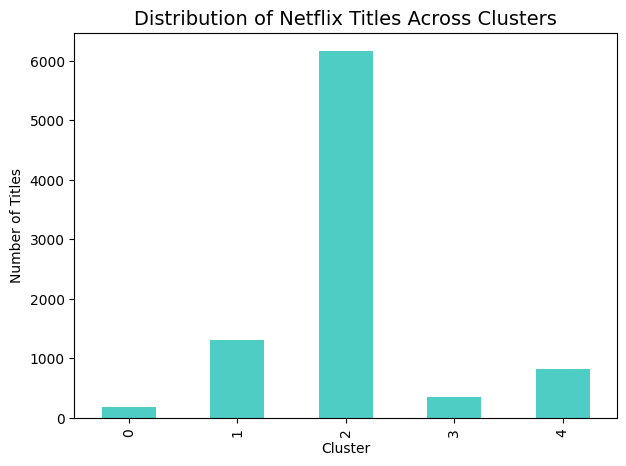

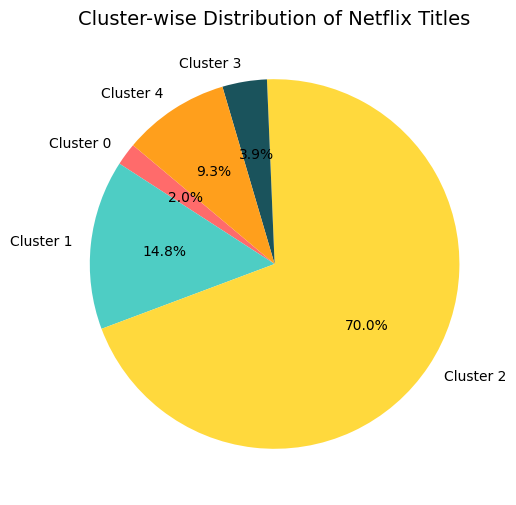

In [0]:
import matplotlib.pyplot as plt

# Count how many titles in each cluster
cluster_counts = df_read['cluster'].value_counts().sort_index()

# ✅ Bar chart
plt.figure(figsize=(7,5))
cluster_counts.plot(kind='bar', color='#4ECDC4')
plt.title("Distribution of Netflix Titles Across Clusters", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")
plt.show()

# ✅ Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    cluster_counts.values,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#FF6B6B','#4ECDC4','#FFD93D','#1A535C','#FF9F1C']
)
plt.title("Cluster-wise Distribution of Netflix Titles", fontsize=14)
plt.show()


In [0]:
# Analyze average duration and common genres per cluster
cluster_summary = df_read.groupby('cluster').agg({
    'duration': 'first',   # just to show examples
    'rating': lambda x: x.value_counts().index[0],  # most common rating
    'listed_in': lambda x: x.value_counts().index[0]  # most common genre combo
}).reset_index()

display(cluster_summary)


cluster,duration,rating,listed_in
0,2 Seasons,TV-MA,"Crime TV Shows, International TV Shows, Spanish-Language TV Shows"
1,125 min,TV-MA,"Dramas, Independent Movies, International Movies"
2,90 min,TV-MA,"Dramas, International Movies"
3,64 min,TV-MA,Stand-Up Comedy
4,1 Season,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas"


/home/spark-b4b8822e-eea8-41a8-96fd-94/.ipykernel/2472/command-6905352878116411-401764041:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['rating'] = le.fit_transform(X['rating'].astype(str))


Accuracy: 0.9994324631101021

Confusion Matrix:
 [[1214    0]
 [   1  547]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



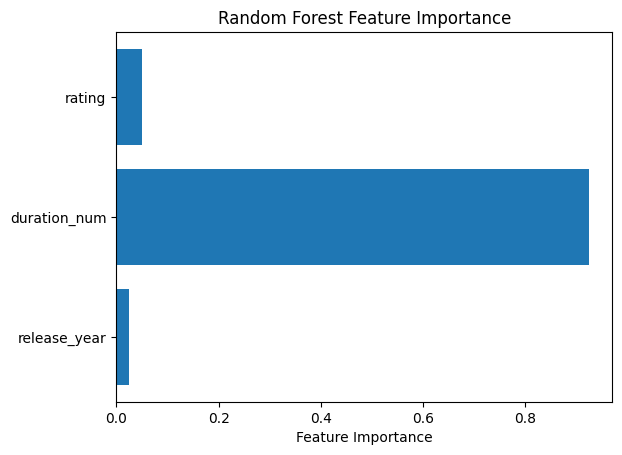

In [0]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ✅ Load the feature-engineered dataset
file_path = "/Volumes/workspace/default/netflixdata/netflix_titles_featured.csv"
df_read = pd.read_csv(file_path)

# Basic preprocessing
df = df.dropna(subset=['type', 'release_year', 'duration', 'rating', 'country', 'listed_in'])

# Feature engineering
# Convert duration to numeric: "90 min" -> 90, "2 Seasons" -> 2
def extract_duration(value):
    if pd.isnull(value):
        return 0
    if 'Season' in value:
        return int(value.split()[0])
    elif 'min' in value:
        return int(value.split()[0])
    else:
        return 0

df['duration_num'] = df['duration'].apply(extract_duration)

# Select features and target
features = ['release_year', 'duration_num', 'rating']
X = df[features]

# Encode categorical rating
le = LabelEncoder()
X['rating'] = le.fit_transform(X['rating'].astype(str))

# Target variable
y = df['type']  # Movie or TV Show
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Optional: Feature importance
import matplotlib.pyplot as plt
import numpy as np

feature_importances = model.feature_importances_
plt.barh(features, feature_importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()


In [0]:

# check counts
type_counts = df['type'].value_counts()
print(type_counts)


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [0]:
print(le.inverse_transform([0,1]))


['Movie' 'TV Show']


In [0]:
cm = confusion_matrix(y_test, y_pred)

# confusion_matrix format: [[Movie as Movie, Movie as TV Show],
#                           [TV Show as Movie, TV Show as TV Show]]
TN = cm[0,0]  # Movie correctly predicted
FP = cm[0,1]  # Movie predicted as TV Show
FN = cm[1,0]  # TV Show predicted as Movie
TP = cm[1,1]  # TV Show correctly predicted

print("True Positive (TV Show correctly predicted):", TP)
print("True Negative (Movie correctly predicted):", TN)
print("False Positive (Predicted TV Show when Movie):", FP)
print("False Negative (Predicted Movie when TV Show):", FN)


True Positive (TV Show correctly predicted): 547
True Negative (Movie correctly predicted): 1214
False Positive (Predicted TV Show when Movie): 0
False Negative (Predicted Movie when TV Show): 1


📊 Feature Importance Table:

             Feature  Importance
0       duration_num    0.777665
1          listed_in    0.198068
2             rating    0.023550
3  Content_Age_Group    0.000717


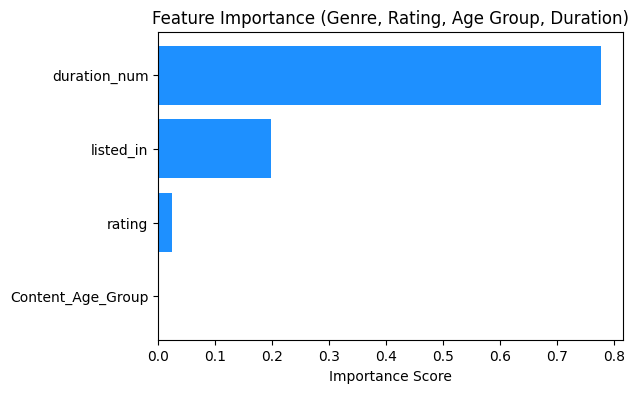

In [0]:
# --- Select required columns ---
df = df.dropna(subset=['type', 'listed_in', 'rating', 'Content_Age_Group', 'duration_num'])

# --- Feature Selection ---
features = ['listed_in', 'rating', 'Content_Age_Group', 'duration_num']
X = df[features].copy()

# --- Encode Categorical Features ---
le = LabelEncoder()
for col in ['listed_in', 'rating', 'Content_Age_Group']:
    X[col] = le.fit_transform(X[col].astype(str))

# --- Target Variable ---
y = LabelEncoder().fit_transform(df['type'])   # Movie vs TV Show

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scale Numerical Features ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Train Random Forest Model ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- Feature Importance ---
importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("📊 Feature Importance Table:\n")
print(importance_df)

# --- Plot Feature Importance ---
plt.figure(figsize=(6,4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='dodgerblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance (Genre, Rating, Age Group, Duration)')
plt.gca().invert_yaxis()
plt.show()



